<a href="https://colab.research.google.com/github/Ravneet-kaur1102/DataScienceTraining/blob/main/Multi_Domain_Business_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



---



# > To generate mock/representative datasets so you can test the code instantly.

---









In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# 1. Generate Mock Sales Dataset
np.random.seed(42)
sales_data = {
    'OrderID': range(1001, 1101),
    'Date': pd.date_range(start='2021-01-01', periods=100, freq='D'),
    'Product_Category': np.random.choice(['Electronics', 'Clothing', 'Home Decor', 'Books'], 100),
    'Sales_Amount': np.random.uniform(20, 500, 100).round(2),
    'Quantity': np.random.randint(1, 5, 100),
    'Region': np.random.choice(['North', 'East', 'South', 'West'], 100)
}
df_sales = pd.DataFrame(sales_data)
df_sales['Profit'] = (df_sales['Sales_Amount'] * np.random.uniform(0.1, 0.4, 100)).round(2)

# 2. Generate Mock COVID-19 Dataset
covid_data = {
    'Date': pd.date_range(start='2020-03-01', periods=100, freq='D'),
    'Country': np.random.choice(['India', 'USA', 'UK', 'Brazil'], 100),
    'New_Cases': np.random.randint(100, 50000, 100),
    'New_Deaths': np.random.randint(5, 1000, 100),
    'Vaccinations_Administered': np.random.randint(1000, 200000, 100)
}
df_covid = pd.DataFrame(covid_data)

# 3. Generate Mock IPL Dataset
ipl_data = {
    'Match_ID': range(1, 61),
    'Season': np.random.choice(['2022', '2023'], 60),
    'Venue': np.random.choice(['Wankhede Stadium', 'Eden Gardens', 'Chinnaswamy Stadium'], 60),
    'Team1': np.random.choice(['MI', 'CSK', 'RCB', 'KKR'], 60),
    'Team2': np.random.choice(['DC', 'GT', 'RR', 'LSG'], 60),
    'Toss_Winner': np.random.choice(['Team1', 'Team2'], 60),
    'Toss_Decision': np.random.choice(['Bat', 'Field'], 60),
    'Winner': np.random.choice(['Team1', 'Team2'], 60),
    'Win_Margin_Runs': np.random.randint(1, 100, 60),
    'Player_of_Match': np.random.choice(['Virat Kohli', 'MS Dhoni', 'Rohit Sharma', 'Hardik Pandya'], 60)
}
df_ipl = pd.DataFrame(ipl_data)
df_ipl['Winner'] = np.where(df_ipl['Winner'] == 'Team1', df_ipl['Team1'], df_ipl['Team2'])
df_ipl['Toss_Winner'] = np.where(df_ipl['Toss_Winner'] == 'Team1', df_ipl['Team1'], df_ipl['Team2'])

print("Datasets successfully initialized!")

Datasets successfully initialized!




---
# Part 2: The 10 Business Questions & Answers
Domain A: Retail Sales Analytics
# Q1: Which product categories yield the highest total sales and overall profit margin?
Business Value: Helps inventory managers identify top revenue drivers and high-margin products to optimize stock levels.


---




In [ ]:
category_perf = df_sales.groupby('Product_Category').agg(
    Total_Sales=('Sales_Amount', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()
category_perf['Profit_Margin_%'] = ((category_perf['Total_Profit'] / category_perf['Total_Sales']) * 100).round(2)

print(category_perf.sort_values(by='Total_Sales', ascending=False))

  Product_Category  Total_Sales  Total_Profit  Profit_Margin_%
0            Books      8325.94       2073.89            24.91
1         Clothing      6042.60       1596.14            26.41
3       Home Decor      5918.20       1234.89            20.87
2      Electronics      5058.93       1344.18            26.57




---
# Q2: Is there a specific geographical region that underperforms in sales volume?
Business Value: Identifies struggling markets where targeted marketing campaigns or discount strategies may be required.
---




/tmp/ipykernel_5149/1737637163.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_perf.index, y=region_perf.values, palette='viridis')


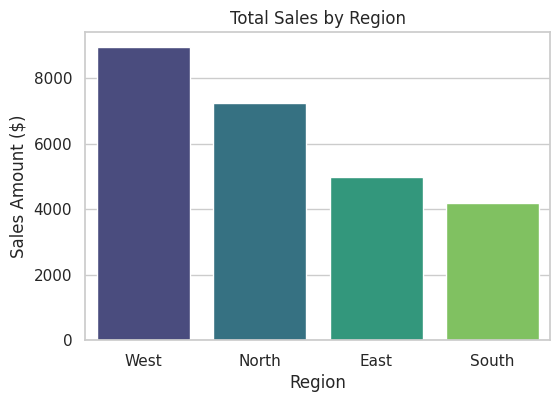

In [ ]:
region_perf = df_sales.groupby('Region')['Sales_Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
sns.barplot(x=region_perf.index, y=region_perf.values, palette='viridis')
plt.title('Total Sales by Region')
plt.ylabel('Sales Amount ($)')
plt.show()



---

# Q3: What is our monthly sales trend, and are we seeing consistent growth?
Business Value: Essential for budgeting, forecasting, and visualizing historical seasonality patterns.


---



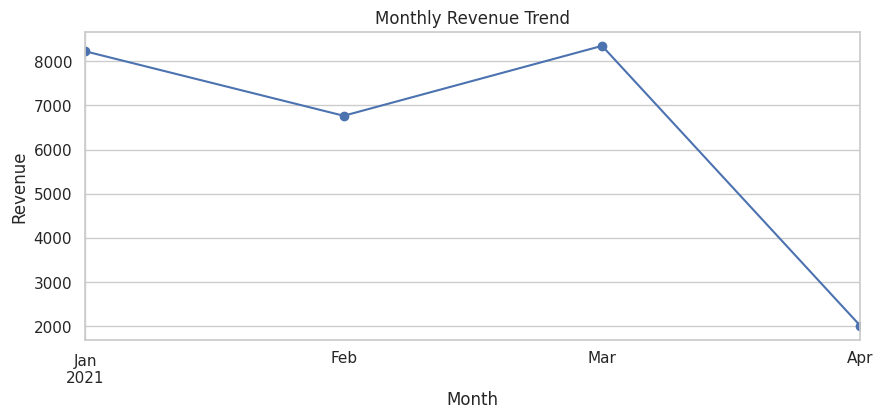

In [ ]:
df_sales['Month'] = df_sales['Date'].dt.to_period('M')
monthly_sales = df_sales.groupby('Month')['Sales_Amount'].sum()

plt.figure(figsize=(10, 4))
monthly_sales.plot(kind='line', marker='o', color='b')
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()



---


# Domain B: COVID-19 Public Health & Impact Analytics
Q4: Which countries have the highest Case Fatality Rate (CFR)?
Business Value: Evaluates public health severity and healthcare infrastructure strength across different countries.


---



In [ ]:
country_covid = df_covid.groupby('Country').agg(
    Total_Cases=('New_Cases', 'sum'),
    Total_Deaths=('New_Deaths', 'sum')
).reset_index()
country_covid['CFR_%'] = ((country_covid['Total_Deaths'] / country_covid['Total_Cases']) * 100).round(2)

print(country_covid.sort_values(by='CFR_%', ascending=False))

  Country  Total_Cases  Total_Deaths  CFR_%
0  Brazil       655720         16762   2.56
3     USA       405418          9196   2.27
2      UK       518682         10456   2.02
1   India       876960         15521   1.77




---


# Q5: Is there a measurable statistical correlation between daily vaccination rollouts and a decline in new cases?
Business Value: Measures the operational efficacy of vaccination campaigns on public infection rates.


---



Pearson Correlation Coefficient between Vaccinations and New Cases: -0.13


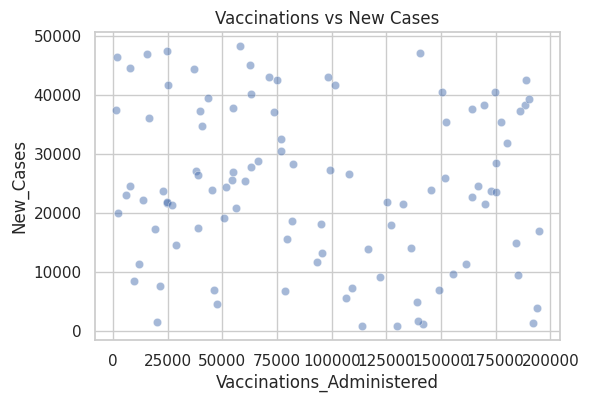

In [16]:
correlation = df_covid['Vaccinations_Administered'].corr(df_covid['New_Cases'])
print(f"Pearson Correlation Coefficient between Vaccinations and New Cases: {correlation:.2f}")

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_covid, x='Vaccinations_Administered', y='New_Cases', alpha=0.5)
plt.title('Vaccinations vs New Cases')
plt.show()

# Option A: Color points based on a third categorical column (e.g., Country)
If you want to see how this relationship splits across different groups, use the hue parameter. This is the most common approach in data analysis.

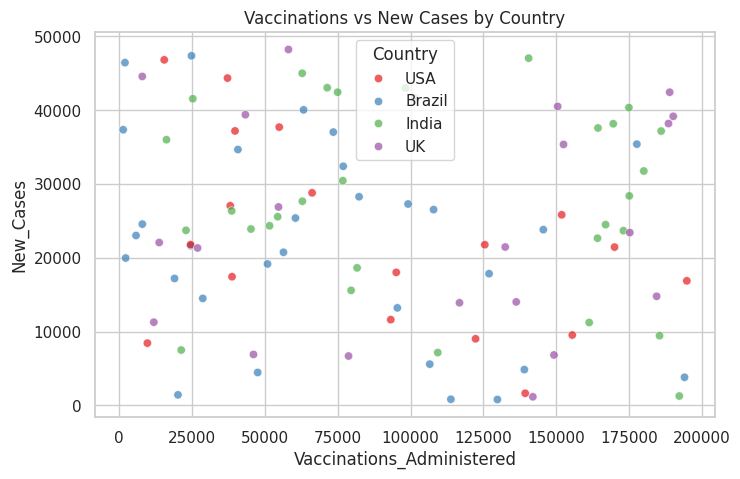

In [17]:
plt.figure(figsize=(8, 5))

# Using 'hue' automatically assigns different colors to different countries
sns.scatterplot(
    data=df_covid,
    x='Vaccinations_Administered',
    y='New_Cases',
    hue='Country',       # <--- This splits data by colors
    palette='Set1',      # Chooses a distinct color palette
    alpha=0.7            # Semi-transparent to handle overlaps
)

plt.title('Vaccinations vs New Cases by Country')
plt.show()

Option B: Plotting both variables over time (Dual Y-Axis Line Plot)
# If your goal is to visually compare the trend of Vaccinations (Color 1) against New Cases (Color 2) across a timeline, a scatter plot won't work well. You need a line chart with a shared X-axis (Date) but separate Y-axes because their numeric scales are vastly different.

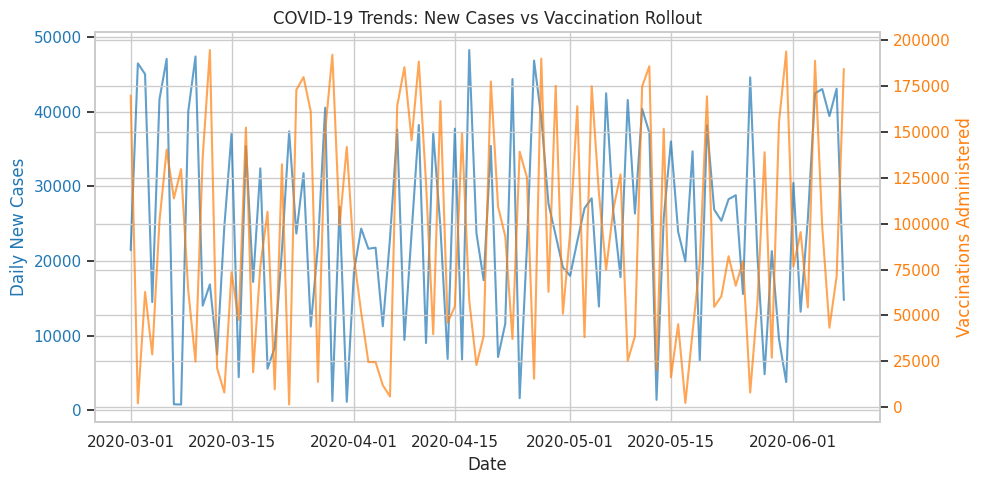

In [18]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plotting New Cases on the left axis (Blue)
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily New Cases', color=color)
sns.lineplot(data=df_covid, x='Date', y='New_Cases', ax=ax1, color=color, alpha=0.7)
ax1.tick_params(axis='y', labelcolor=color)

# Instantiating a second axes that shares the same x-axis
ax2 = ax1.twinx()

# Plotting Vaccinations on the right axis (Orange)
color = 'tab:orange'
ax2.set_ylabel('Vaccinations Administered', color=color)
sns.lineplot(data=df_covid, x='Date', y='Vaccinations_Administered', ax=ax2, color=color, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('COVID-19 Trends: New Cases vs Vaccination Rollout')
fig.tight_layout()
plt.show()



---


# Q6: What did the peak timeline look like for global daily infections across different countries?
Business Value: Helps policymakers track virus waves to allocate emergency medical resources efficiently.


---



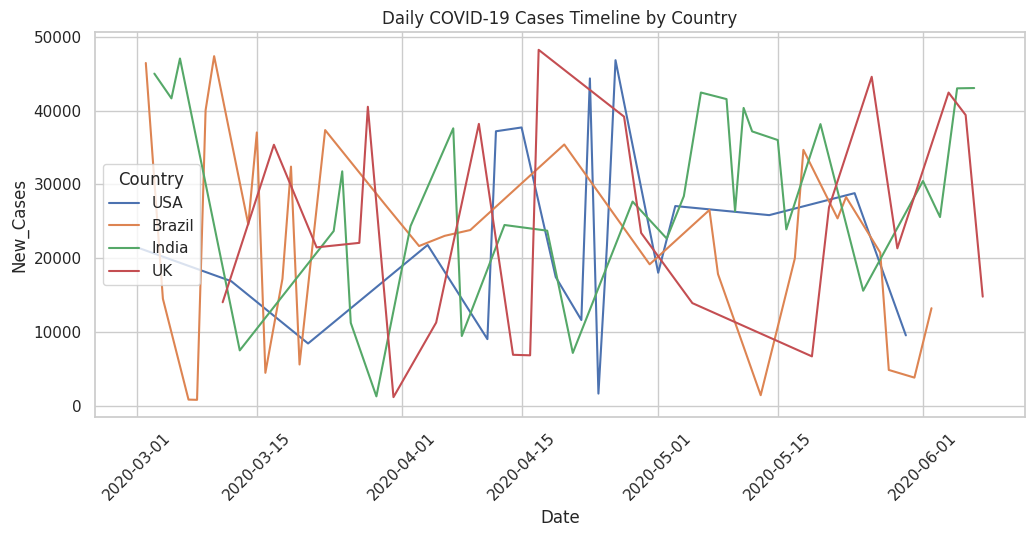

In [ ]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_covid, x='Date', y='New_Cases', hue='Country')
plt.title('Daily COVID-19 Cases Timeline by Country')
plt.xticks(rotation=45)
plt.show()



---


# Domain C: IPL Sports Analytics
Q7: Does winning the toss grant a significant strategic advantage in winning the match?
Business Value: Highly valuable insight for team strategies, sports analytics, and predictive modeling for match outcomes.


---



In [9]:
df_ipl['Toss_Match_Winner'] = np.where(df_ipl['Toss_Winner'] == df_ipl['Winner'], 'Won Match', 'Lost Match')
toss_advantage = df_ipl['Toss_Match_Winner'].value_counts(normalize=True) * 100

print("Percentage of teams winning the match after winning the toss:")
print(toss_advantage.round(2))

Percentage of teams winning the match after winning the toss:
Toss_Match_Winner
Won Match     58.33
Lost Match    41.67
Name: proportion, dtype: float64




---


# Q8: At which stadium venues should teams favor fielding first over batting first based on historical results?
Business Value: Guides team captains on pitch behavior and optimal match-day strategy.


---



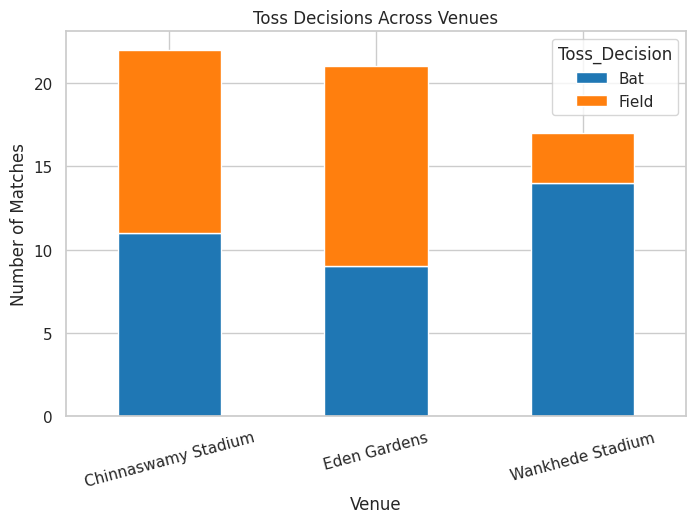

In [10]:
venue_decision = df_ipl.groupby(['Venue', 'Toss_Decision']).size().unstack(fill_value=0)
venue_decision.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#1f77b4', '#ff7f0e'])
plt.title('Toss Decisions Across Venues')
plt.ylabel('Number of Matches')
plt.xticks(rotation=15)
plt.show()



---


# Q9: Who are the top 3 most valuable players (MVP) judged by 'Player of the Match' awards?
Business Value: Critical information for franchise managers during player auctions and brand endorsement valuations.


---



In [11]:
top_mvps = df_ipl['Player_of_Match'].value_counts().head(3)
print("Top 3 Players of the Match Recipients:")
print(top_mvps)

Top 3 Players of the Match Recipients:
Player_of_Match
Virat Kohli      19
Hardik Pandya    15
Rohit Sharma     15
Name: count, dtype: int64




---


# Q10: Which team has been historically dominant, achieving the highest overall win percentage?
Business Value: Measures overall franchise success and brand equity across multiple tournament seasons.


---



In [12]:
# Calculate total matches played per team
matches_as_team1 = df_ipl['Team1'].value_counts()
matches_as_team2 = df_ipl['Team2'].value_counts()
total_matches = matches_as_team1.add(matches_as_team2, fill_value=0)

# Calculate wins per team
total_wins = df_ipl['Winner'].value_counts()

# Calculate Win %
team_stats = pd.DataFrame({'Matches': total_matches, 'Wins': total_wins})
team_stats['Win_Percentage'] = ((team_stats['Wins'] / team_stats['Matches']) * 100).round(2)

print(team_stats.sort_values(by='Win_Percentage', ascending=False))

     Matches  Wins  Win_Percentage
LSG     16.0    12           75.00
RCB     12.0     7           58.33
CSK     19.0    10           52.63
KKR     12.0     6           50.00
MI      17.0     8           47.06
RR      17.0     7           41.18
GT      16.0     6           37.50
DC      11.0     4           36.36


# What you need to do?


---

Part 3: Next Steps to Elevate Your Portfolio
To make this notebook ready for your GitHub portfolio or a technical review, consider adding these enhancements:

Connect Real Data: Replace the mock code blocks with pd.read_csv('your_path.csv') using genuine open-source datasets from Kaggle (e.g., COVID-19 Open Data, IPL Complete Dataset (2008-2024), or Superstore Sales Dataset).

Cross-Domain Feature Engineering: Add an advanced bonus section checking if COVID-19 lock-downs directly impacted retail store sales trends or if empty stadium IPL matches altered home-team advantages.